## Spam Email Detection 

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\suman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [117]:
data = pd.read_csv('spam_ham_dataset.csv')

In [118]:
data.head(12)

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
5,2949,ham,Subject: ehronline web address change\r\nthis ...,0
6,2793,ham,Subject: spring savings certificate - take 30 ...,0
7,4185,spam,Subject: looking for medication ? we ` re the ...,1
8,2641,ham,Subject: noms / actual flow for 2 / 26\r\nwe a...,0
9,1870,ham,"Subject: nominations for oct . 21 - 23 , 2000\...",0


In [119]:
data.shape

(5171, 4)

In [120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [121]:
data.isnull().sum()

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

In [122]:
data.duplicated().sum()

np.int64(0)

In [123]:
print(data['label'].value_counts())

label
ham     3672
spam    1499
Name: count, dtype: int64


In [124]:
print(data['label'].value_counts(normalize=True)*100)

label
ham     71.01141
spam    28.98859
Name: proportion, dtype: float64


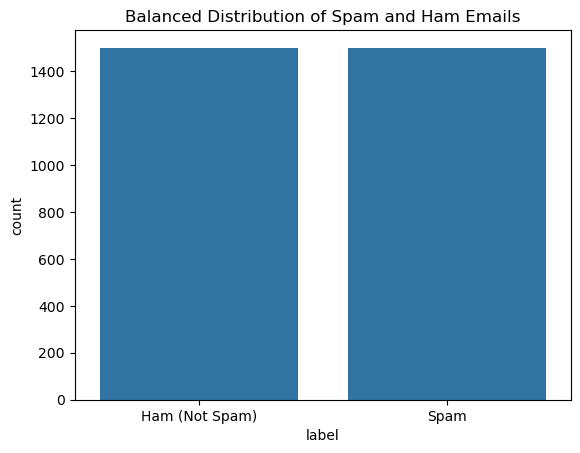

In [125]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()

In [126]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [127]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

balanced_data['text'] = balanced_data['text'].apply(remove_punctuation)

In [128]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)

    return output


balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head(8)

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0
5,3295,ham,lufkin may 27 th lufkin industrial market go 5...,0
6,205,ham,equistar fyi activity rescheduled reallocated ...,0
7,1172,ham,interview schedule liz bellamy today attached ...,0


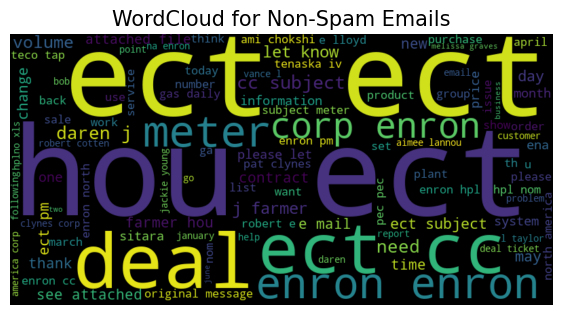

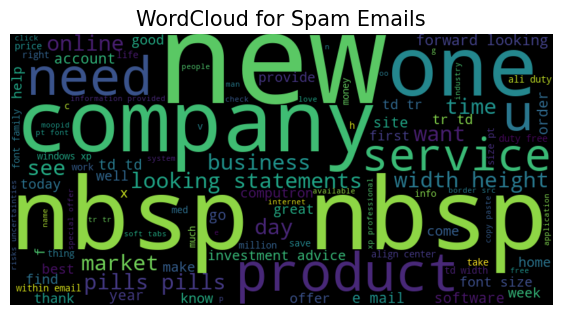

In [129]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

In [130]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

In [131]:
import pickle

with open("backend/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [132]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=32,
        input_length=max_len
    ),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [133]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5613 - loss: 0.6784 - val_accuracy: 0.6283 - val_loss: 0.6295 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7794 - loss: 0.4768 - val_accuracy: 0.9483 - val_loss: 0.2531 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8837 - loss: 0.3488 - val_accuracy: 0.8767 - val_loss: 0.3439 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8912 - loss: 0.3192 - val_accuracy: 0.8967 - val_loss: 0.3055 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9037 - loss: 0.2917 - val_accuracy: 0.9000 - val_loss: 0.2985 - learning_rate: 5.0000e-04


In [85]:
model.save("backend/spam_model.keras")

In [97]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9583 - loss: 0.1579
Test Loss : 0.1579098105430603
Test Accuracy : 0.9583333134651184


In [87]:
predictions = (
    model.predict(test_sequences) > 0.5
).astype("int32")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


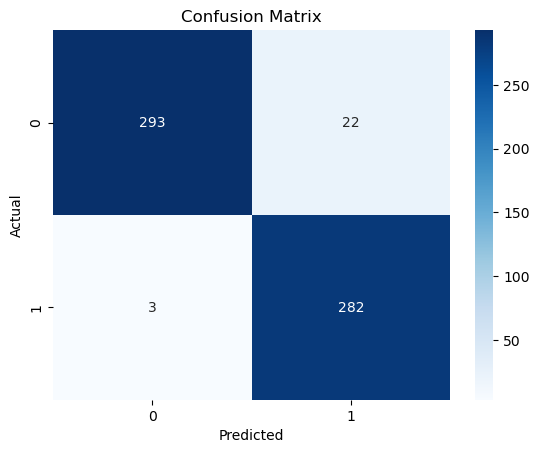

In [88]:
cm = confusion_matrix(test_Y, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [89]:
print(classification_report(
    test_Y,
    predictions,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.99      0.93      0.96       315
        Spam       0.93      0.99      0.96       285

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



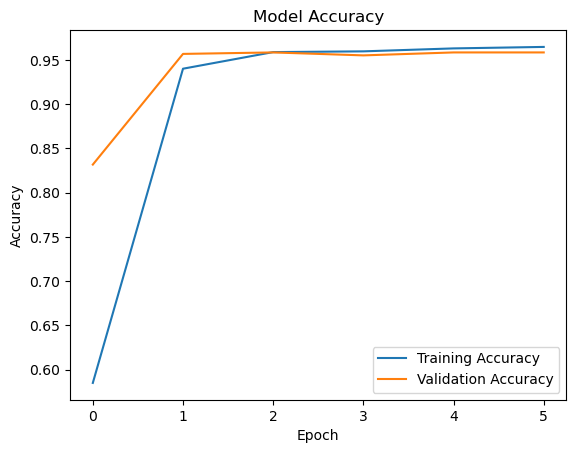

In [90]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

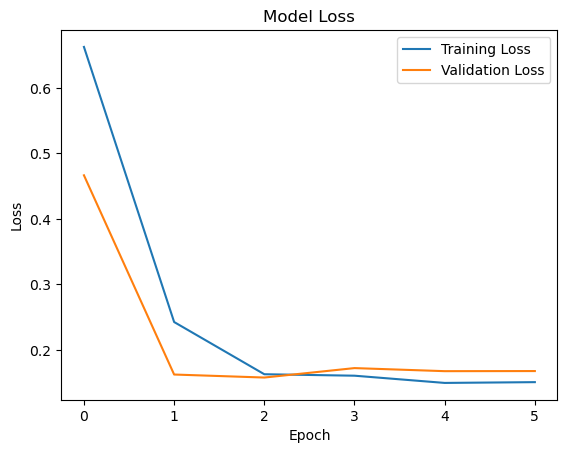

In [91]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [93]:
def predict_spam(message):
    sequence = tokenizer.texts_to_sequences([message])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='post',
        truncating='post'
    )

    prediction = model.predict(padded, verbose=0)[0][0]

    if prediction >= 0.5:
        print("Spam")
    else:
        print("Ham")

In [135]:
predict_spam("Congratulations! You have won a free prize!")

Prediction Score: 0.8452606
Spam


In [134]:
predict_spam("Hey, are we meeting for lunch today?")

Prediction Score: 0.8452606
Spam


In [62]:
import os
print(os.getcwd())

d:\Spam-Ham-Email-Classification


In [65]:
import os

print(os.path.getsize("backend/spam_model.keras"))
print(os.path.getsize("backend/tokenizer.pkl"))

15376373
1590420


In [94]:
print(train_Y.value_counts())
print(test_Y.value_counts())

label
1    1214
0    1184
Name: count, dtype: int64
label
0    315
1    285
Name: count, dtype: int64


In [136]:
predict_spam("Hello, how are you today?")

Prediction Score: 0.8452606
Spam


In [137]:
predict_spam("Congratulations! You have won a free prize. Click now!")

Prediction Score: 0.8452606
Spam


In [98]:
prediction = model.predict(test_sequences, verbose=0)

print(prediction[:10].flatten())

[0.01213578 0.01376012 0.01213579 0.9385723  0.0137941  0.01213578
 0.93857116 0.01213584 0.91488874 0.9385723 ]


In [99]:
def predict_spam(message):
    sequence = tokenizer.texts_to_sequences([message])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='post',
        truncating='post'
    )

    prediction = model.predict(padded, verbose=0)[0][0]

    print("Prediction Score:", prediction)

    if prediction >= 0.5:
        print("Spam")
    else:
        print("Ham")

In [138]:
predict_spam("Hello, how are you today?")

Prediction Score: 0.8452606
Spam


In [139]:
predict_spam("Congratulations! You have won a free prize. Click now!")

Prediction Score: 0.8452606
Spam


In [102]:
p1 = model.predict(
    pad_sequences(
        tokenizer.texts_to_sequences(["Hello, how are you today?"]),
        maxlen=max_len,
        padding='post',
        truncating='post'
    ),
    verbose=0
)[0][0]

p2 = model.predict(
    pad_sequences(
        tokenizer.texts_to_sequences(["Congratulations! You have won a free prize. Click now!"]),
        maxlen=max_len,
        padding='post',
        truncating='post'
    ),
    verbose=0
)[0][0]

print("Normal message score:", p1)
print("Spam message score:", p2)

Normal message score: 0.9385723
Spam message score: 0.9385723


In [103]:
print(tokenizer.texts_to_sequences(["Hello, how are you today?"]))
print(tokenizer.texts_to_sequences(["Congratulations! You have won a free prize. Click now!"]))

[[797, 100]]
[[2476, 83, 872, 115]]


In [104]:
print(train_sequences.shape)
print(test_sequences.shape)
print(train_Y.shape)
print(test_Y.shape)

(2398, 100)
(600, 100)
(2398,)
(600,)


In [105]:
print(train_sequences[0][:20])
print(train_Y.iloc[0] if hasattr(train_Y, 'iloc') else train_Y[0])

[  306    48   417   367 11307   107   285    54    79   226   852   232
   604   675    25    71   923    26 17860 17861]
1


In [106]:
print(model.predict(train_sequences[:10], verbose=0).flatten())

[0.93857074 0.93856984 0.93857074 0.9385384  0.90603155 0.9385723
 0.01213605 0.9385723  0.01213626 0.01213592]


In [110]:
print("Train X shape:", train_sequences.shape)
print("Train Y shape:", train_Y.shape)

print("\nFirst 5 training sequences:")
print(train_sequences[:5])

print("\nFirst 5 labels:")
print(train_Y[:5])

Train X shape: (2398, 100)
Train Y shape: (2398,)

First 5 training sequences:
[[  306    48   417   367 11307   107   285    54    79   226   852   232
    604   675    25    71   923    26 17860 17861   752   126 11308   724
  17862 17863 17864  3304 11309   191 11310   972   438  1948  1768  2314
  17865 11311   952   104    40   122  1227   626    26   126    16 17866
  17867     5    76 17868   226     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0]
 [  713   241   523  6799   279  2032   893  1191    14  8399  1656  3732
    714  5237   537   451  2417  2032  3504  2128   228   283  1480  3504
   5895   451  2417  4753 17869 17870   973 11312 17871   171 11313  1295
   2315 11313  1890   663   283  1657  1480   284  3505  1657   543  2129
     3

In [111]:
print("Unique labels:", train_Y.unique())
print(train_Y.value_counts())

Unique labels: [1 0]
label
1    1214
0    1184
Name: count, dtype: int64


In [112]:
predictions = model.predict(train_sequences[:10], verbose=0)

print(predictions.flatten())

[0.4969736  0.49697566 0.49697617 0.49698263 0.4990389  0.49697503
 0.49697515 0.49697527 0.4969755  0.49697417]


In [113]:
print("Actual labels:")
print(train_Y[:10].values)

print("Predicted scores:")
print(predictions.flatten())

Actual labels:
[1 1 1 1 0 1 0 1 0 0]
Predicted scores:
[0.4969736  0.49697566 0.49697617 0.49698263 0.4990389  0.49697503
 0.49697515 0.49697527 0.4969755  0.49697417]


In [114]:
print(model.evaluate(train_sequences, train_Y, verbose=0))
print(model.evaluate(test_sequences, test_Y, verbose=0))

[0.693187415599823, 0.4979149401187897]
[0.6929334402084351, 0.5249999761581421]


In [140]:
loss, accuracy = model.evaluate(test_sequences, test_Y)

print("Test Accuracy:", accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9483 - loss: 0.2531
Test Accuracy: 0.9483333230018616


In [141]:
predict_spam("Hello, how are you today?")

Prediction Score: 0.8452606
Spam


In [142]:
predict_spam("Congratulations! You have won a free prize. Click now!")

Prediction Score: 0.8452606
Spam
